In [7]:
!pip install jupyterlab
!pip install jupyterlab-extensions

In [8]:
#Installs
!pip install scanpy
!pip install numpy
!pip install pandas
!pip install scikit-learn
!pip install matplotlib
!pip install seaborn
!pip install decoupler

In [9]:
#load data
import scanpy as sc
import anndata as ad
import numpy as np

In [10]:
#Import dataset
mock_adata = sc.read_10x_mtx ('data/GSE166766_RAW/Mock')
day_one = sc.read_10x_mtx ('data/GSE166766_RAW/1dpi')
day_two = sc.read_10x_mtx ('data/GSE166766_RAW/2dpi')
day_three = sc.read_10x_mtx ('data/GSE166766_RAW/3dpi')

In [11]:
#checking dataset
print(mock_adata)
print(day_one)
print(day_two)
print(day_three)

AnnData object with n_obs × n_vars = 22609 × 33539
    var: 'gene_ids', 'feature_types'
AnnData object with n_obs × n_vars = 11834 × 33539
    var: 'gene_ids', 'feature_types'
AnnData object with n_obs × n_vars = 14695 × 33539
    var: 'gene_ids', 'feature_types'
AnnData object with n_obs × n_vars = 28530 × 33539
    var: 'gene_ids', 'feature_types'


In [12]:
mock_adata.var.head()
day_one.var.head()
day_two.var.head()
day_three.var.head()

,gene_ids,feature_types
MIR1302-2HG,ENSG00000243485,Gene Expression
FAM138A,ENSG00000237613,Gene Expression
OR4F5,ENSG00000186092,Gene Expression
AL627309.1,ENSG00000238009,Gene Expression
AL627309.3,ENSG00000239945,Gene Expression


In [13]:
#Quality Control

#mock
mock_adata.var['MT'] = mock_adata.var_names.str.startswith("MT-")
mock_adata.var['RIBO'] = mock_adata.var_names.str.startswith(("RPS", "RPL"))
mock_adata.var['HB'] = mock_adata.var_names.str.startswith("^HB[^(P)]")

#day_one
day_one.var['MT'] = day_one.var_names.str.startswith("MT-")
day_one.var['RIBO'] = day_one.var_names.str.startswith(("RPS", "RPL"))
day_one.var['HB'] = day_one.var_names.str.startswith("^HB[^(P)]")

#day_two
day_two.var['MT'] = day_two.var_names.str.startswith("MT-")
day_two.var['RIBO'] = day_two.var_names.str.startswith(("RPS", "RPL"))
day_two.var['HB'] = day_two.var_names.str.startswith("^HB[^(P)]")

#day_three
day_three.var['MT'] = day_three.var_names.str.startswith("MT-")
day_three.var['RIBO'] = day_three.var_names.str.startswith(("RPS", "RPL"))
day_three.var['HB'] = day_three.var_names.str.startswith("^HB[^(P)]")

In [14]:
#mock
sc.pp.calculate_qc_metrics(
    mock_adata, qc_vars=["MT", 'RIBO', 'HB'], inplace=True, log1p=True
)

#day_one
sc.pp.calculate_qc_metrics(
    day_one, qc_vars=["MT", 'RIBO', 'HB'], inplace=True, log1p=True
)

#day_two
sc.pp.calculate_qc_metrics(
    day_two, qc_vars=["MT", 'RIBO', 'HB'], inplace=True, log1p=True
)

#day_three
sc.pp.calculate_qc_metrics(
    day_three, qc_vars=["MT", 'RIBO', 'HB'], inplace=True, log1p=True
)

In [15]:
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (5,4)  # Adjust figure size
plt.rcParams["axes.grid"] = True  # Add grid to plots
plt.rcParams["axes.edgecolor"] = "black" # Set plot border color
plt.rcParams["axes.linewidth"] = 1.5 # Set plot border width
plt.rcParams["axes.facecolor"] = "white" # Set background color
plt.rcParams["axes.labelcolor"] = "black" # Set label color
plt.rcParams["xtick.color"] = "black" # Set x-axis tick color
plt.rcParams["ytick.color"] = "black" # Set y-axis tick color
plt.rcParams["text.color"] = "black" # Set text color

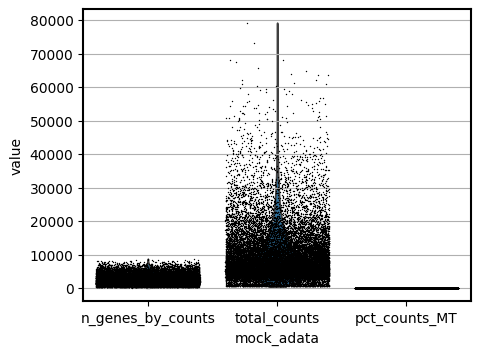

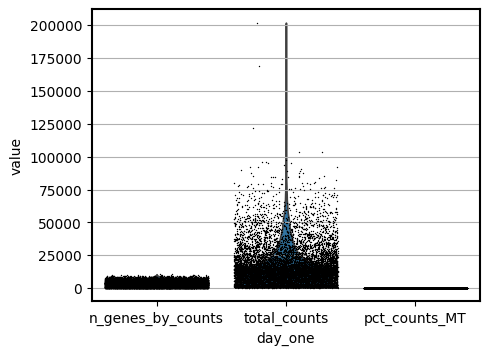

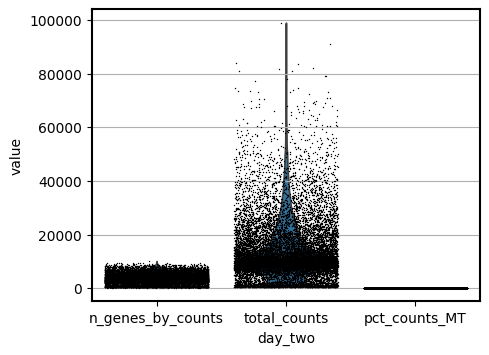

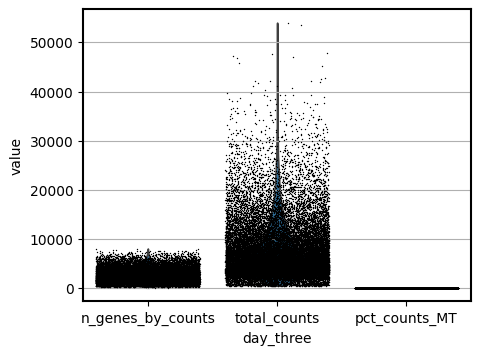

In [16]:
#mock_adata
sc.pl.violin(
    mock_adata,
    ["n_genes_by_counts", 'total_counts', 'pct_counts_MT'],
    jitter=0.4,
    xlabel="mock_adata",
    multi_panel=False,
)

#day_one
sc.pl.violin(
    day_one,
    ["n_genes_by_counts", 'total_counts', 'pct_counts_MT'],
    jitter=0.4,
    xlabel="day_one",
    multi_panel=False,
)

#day_two
sc.pl.violin(
    day_two,
    ["n_genes_by_counts", 'total_counts', 'pct_counts_MT'],
    jitter=0.4,
    xlabel="day_two",
    multi_panel=False,
)

#day_three
sc.pl.violin(
    day_three,
    ["n_genes_by_counts", 'total_counts', 'pct_counts_MT'],
    jitter=0.4,
    xlabel="day_three",
    multi_panel=False,
)

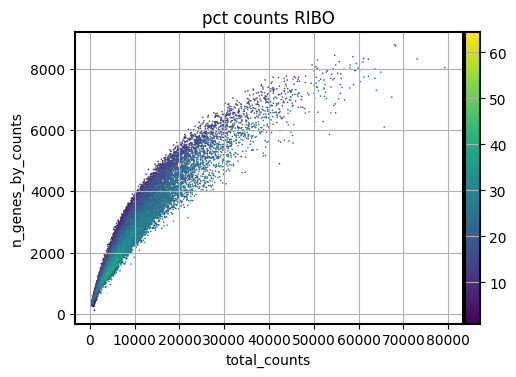

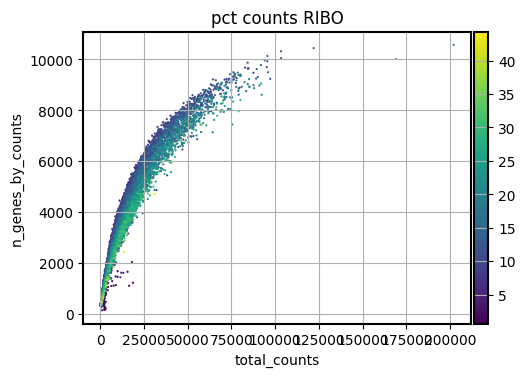

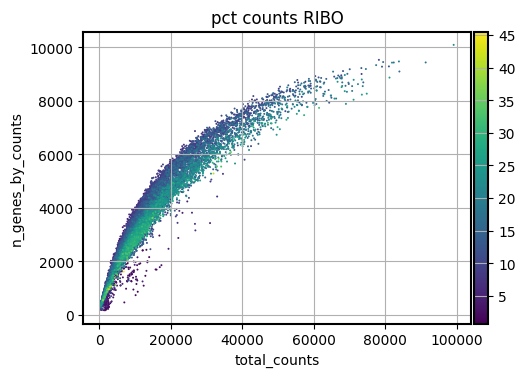

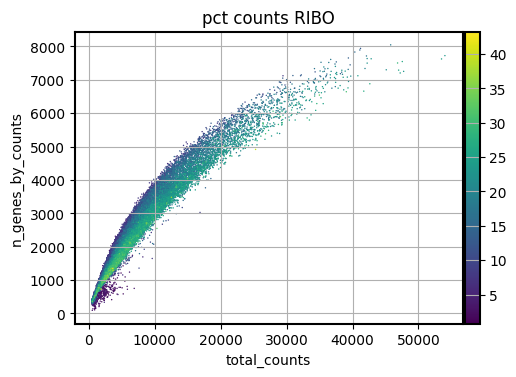

In [17]:
#mock
sc.pl.scatter(mock_adata, "total_counts", "n_genes_by_counts", color="pct_counts_RIBO")

#day_one
sc.pl.scatter(day_one, "total_counts", "n_genes_by_counts", color="pct_counts_RIBO")

#day_two
sc.pl.scatter(day_two, "total_counts", "n_genes_by_counts", color="pct_counts_RIBO")

#day_three
sc.pl.scatter(day_three, "total_counts", "n_genes_by_counts", color="pct_counts_RIBO")


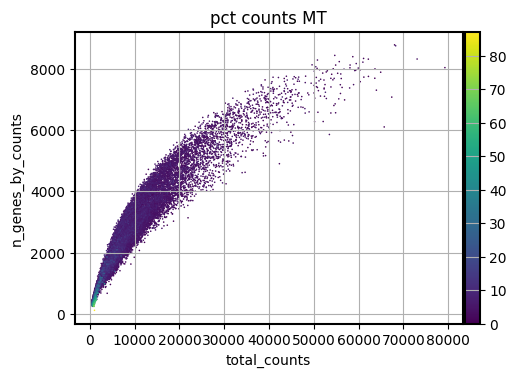

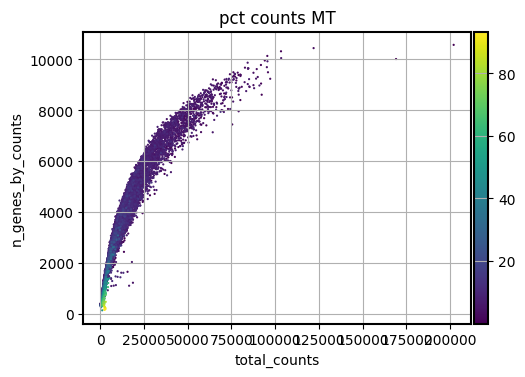

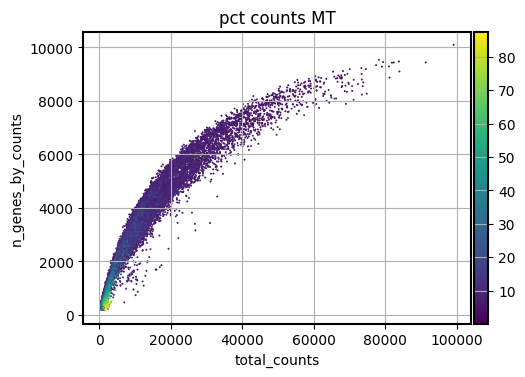

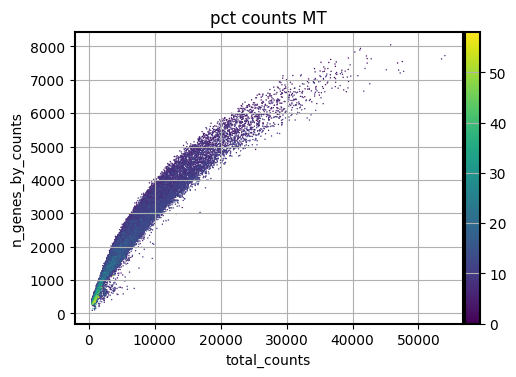

In [18]:
#mock
sc.pl.scatter(mock_adata, "total_counts", "n_genes_by_counts", color="pct_counts_MT")

#day_one
sc.pl.scatter(day_one, "total_counts", "n_genes_by_counts", color="pct_counts_MT")

#day_two
sc.pl.scatter(day_two, "total_counts", "n_genes_by_counts", color="pct_counts_MT")

#day_three
sc.pl.scatter(day_three, "total_counts", "n_genes_by_counts", color="pct_counts_MT")

In [19]:
#filter data
#mock
sc.pp.filter_cells(mock_adata, min_genes=200)
sc.pp.filter_genes(mock_adata, min_cells=3)

#day_one
sc.pp.filter_cells(day_one, min_genes=200)
sc.pp.filter_genes(day_one, min_cells=3)

#day_two
sc.pp.filter_cells(day_two, min_genes=200)
sc.pp.filter_genes(day_two, min_cells=3)

#day_three
sc.pp.filter_cells(day_three, min_genes=200)
sc.pp.filter_genes(day_three, min_cells=3)

In [20]:
#Normalization

#mock
mock_adata.layers["counts"] = mock_adata.X.copy() #save a copy
sc.pp.normalize_total(mock_adata) #Normalize to median total count
sc.pp.log1p(mock_adata) #log data

#day_one
day_one.layers["counts"] = day_one.X.copy()
sc.pp.normalize_total(day_one)
sc.pp.log1p(day_one)

#day_two
day_two.layers["counts"] = day_two.X.copy()
sc.pp.normalize_total(day_two)
sc.pp.log1p(day_two)

#day_three
day_three.layers["counts"] = day_three.X.copy()
sc.pp.normalize_total(day_three)
sc.pp.log1p(day_three)

In [21]:
#feature selection

#mock
sc.pp.highly_variable_genes(mock_adata, n_top_genes=1000)

#day_one
sc.pp.highly_variable_genes(day_one, n_top_genes=1000)

#day_two
sc.pp.highly_variable_genes(day_two, n_top_genes=1000)

#day_three
sc.pp.highly_variable_genes(day_three, n_top_genes=1000)

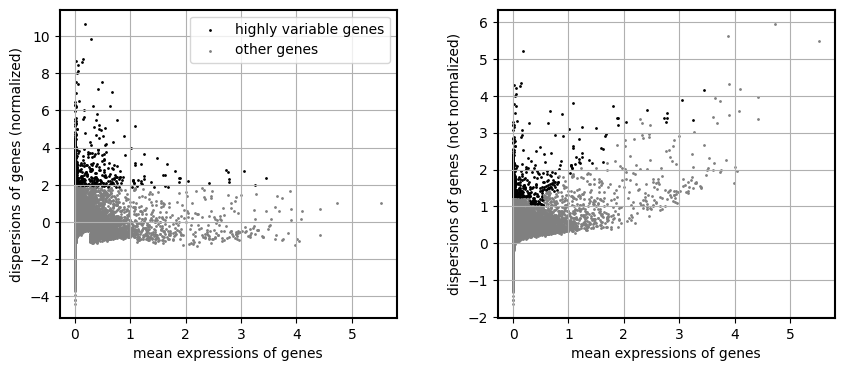

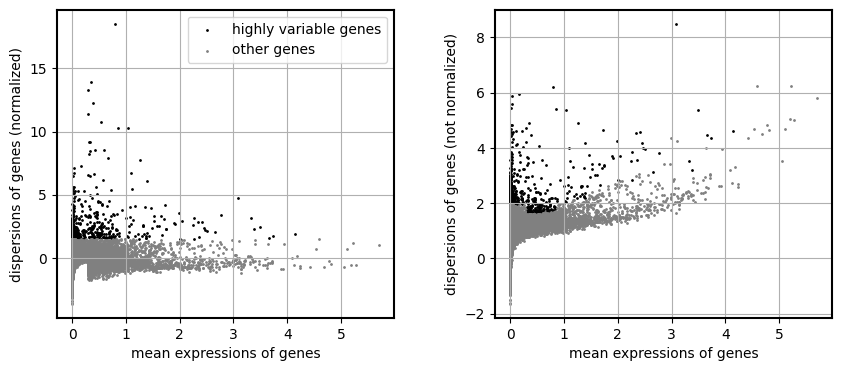

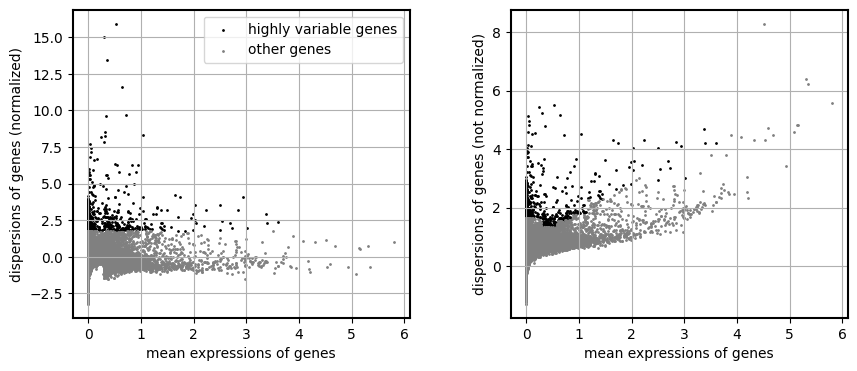

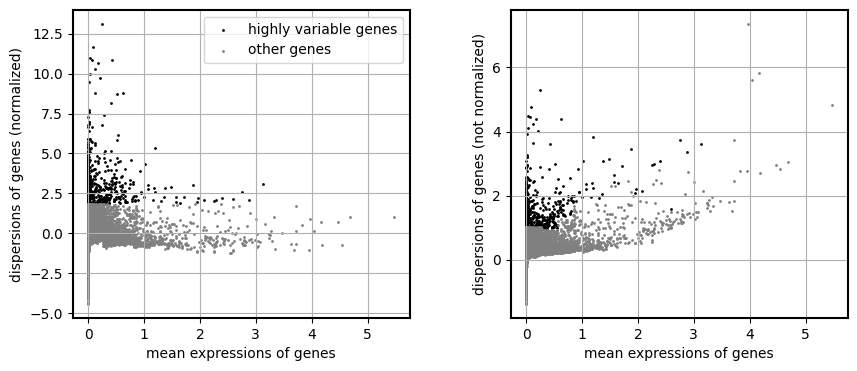

In [22]:
sc.pl.highly_variable_genes(mock_adata)
sc.pl.highly_variable_genes(day_one)
sc.pl.highly_variable_genes(day_two)
sc.pl.highly_variable_genes(day_three)


In [23]:
#Dim reduction
sc.tl.pca(mock_adata)
sc.tl.pca(day_one)
sc.tl.pca(day_two)
sc.tl.pca(day_three)

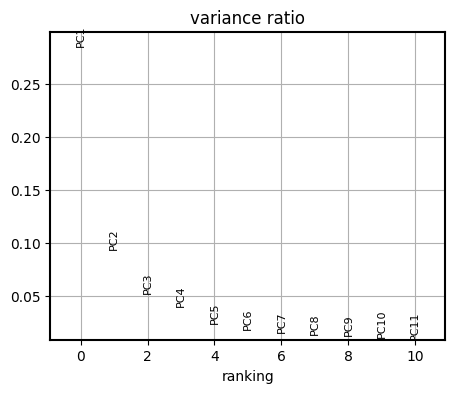

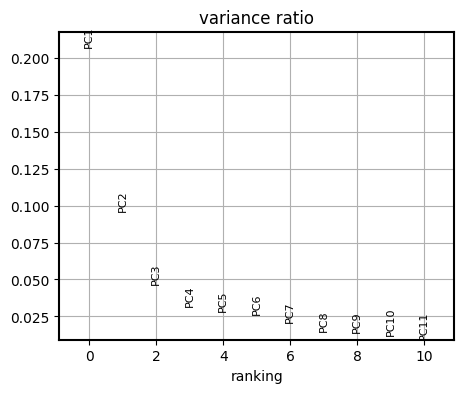

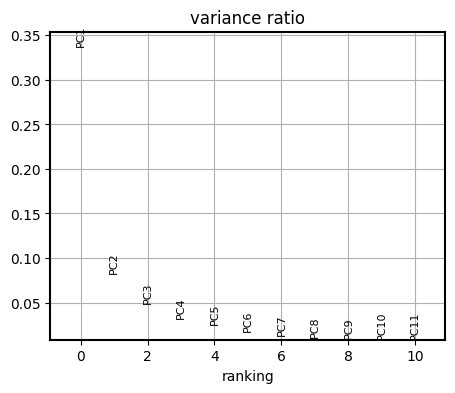

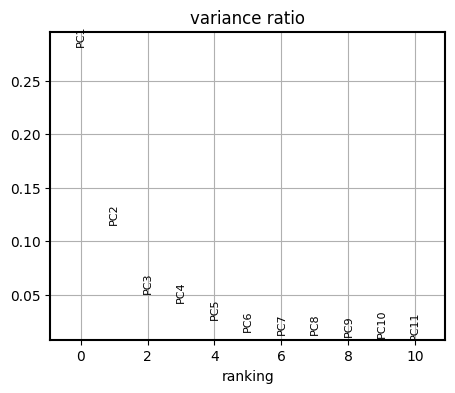

In [24]:
#plotting the variance ratio
sc.pl.pca_variance_ratio(mock_adata, n_pcs=10, log=False)
sc.pl.pca_variance_ratio(day_one, n_pcs=10, log=False)
sc.pl.pca_variance_ratio(day_two, n_pcs=10, log=False)
sc.pl.pca_variance_ratio(day_three, n_pcs=10, log=False)

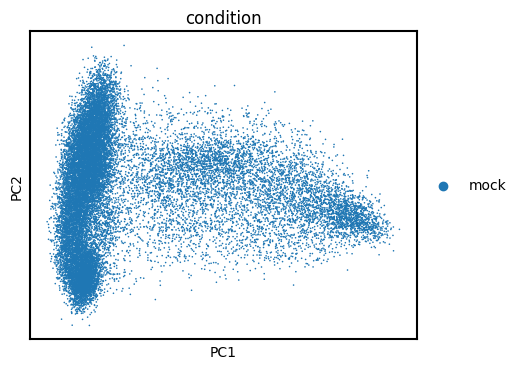

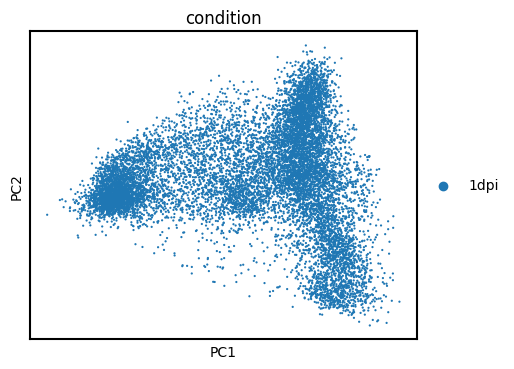

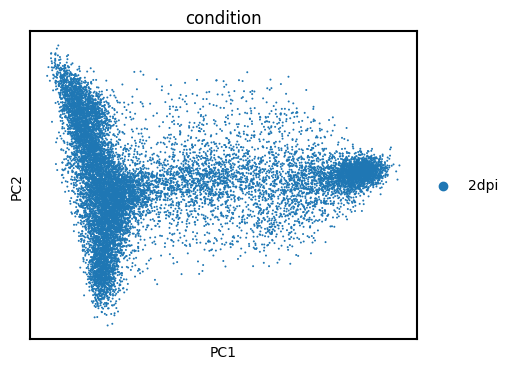

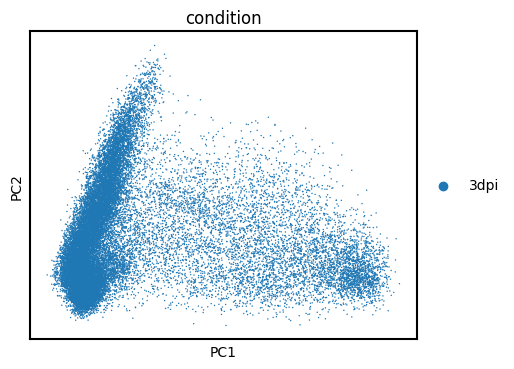

In [25]:
# Assign 'condition' metadata to each AnnData object
mock_adata.obs['condition'] = 'mock'
day_one.obs['condition'] = '1dpi'
day_two.obs['condition'] = '2dpi'
day_three.obs['condition'] = '3dpi'

#mock
sc.pl.pca(
    mock_adata,
    color=['condition'],
    cmap='coolwarm')

#day_one
sc.pl.pca(
    day_one,
    color=['condition'],
    cmap='coolwarm')

#day_two
sc.pl.pca(
    day_two,
    color=['condition'],
    cmap='coolwarm')

#day_three
sc.pl.pca(
    day_three,
    color=['condition'],
    cmap='coolwarm')

In [26]:
#find nearest neighbour
#mock
sc.pp.neighbors(mock_adata)
sc.tl.umap(mock_adata)

#day_one
sc.pp.neighbors(day_one)
sc.tl.umap(day_one)

#day_two
sc.pp.neighbors(day_two)
sc.tl.umap(day_two)

#day_three
sc.pp.neighbors(day_three)
sc.tl.umap(day_three)

/Users/taghwomills/PycharmProjects/JupyterProjectTestPraise/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [27]:
! pip install igraph

In [28]:
#Clustering
#mock
sc.tl.leiden(mock_adata, flavor="igraph", n_iterations=10, key_added="leiden_res_", resolution=0.25)
#day_one
sc.tl.leiden(day_one, flavor="igraph", n_iterations=10, key_added="leiden_res_", resolution=0.25)
#day_two
sc.tl.leiden(day_two, flavor="igraph", n_iterations=10, key_added="leiden_res_", resolution=0.25)
#day_three
sc.tl.leiden(day_three, flavor="igraph", n_iterations=10, key_added="leiden_res_", resolution=0.25)

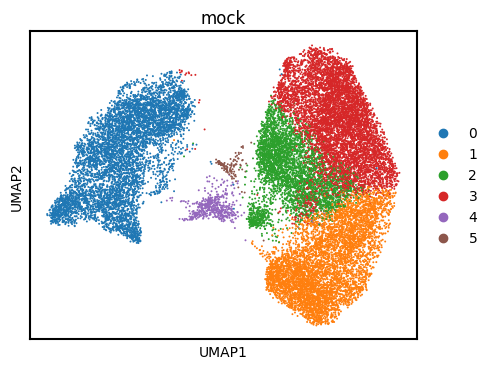

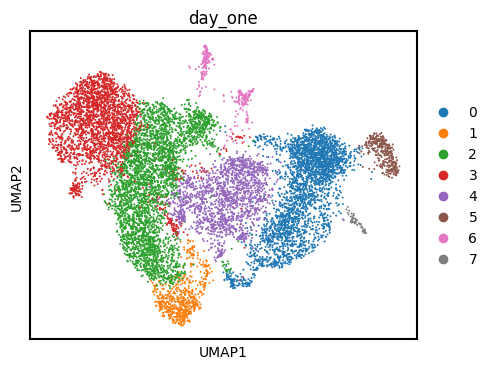

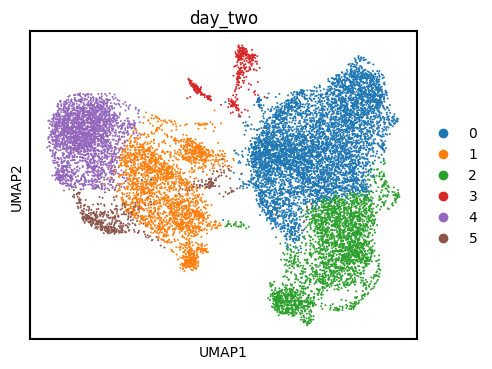

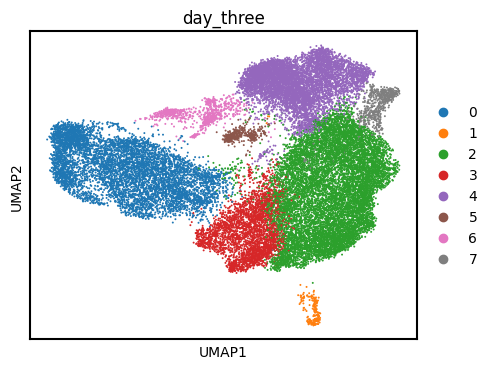

In [29]:
sc.pl.umap(
    mock_adata,
    color=["leiden_res_"],
    size=8,
    wspace=0.5,
    ncols = 1,
    title = 'mock'
)

sc.pl.umap(
    day_one,
    color=["leiden_res_"],
    size=8,
    wspace=0.5,
    ncols = 1,
    title = 'day_one'
)

sc.pl.umap(
    day_two,
    color=["leiden_res_"],
    size=8,
    wspace=0.5,
    ncols = 1,
    title = 'day_two'
)

sc.pl.umap(
    day_three,
    color=["leiden_res_"],
    size=8,
    wspace=0.5,
    ncols = 1,
    title = 'day_three'
)

In [30]:
import decoupler as dc

In [31]:
#Query Omnipath and get PanglaoDB
markers = dc.op.resource(name="PanglaoDB", organism="human")

In [32]:
markers.head()

,genesymbol,canonical_marker,cell_type,germ_layer,human,human_sensitivity,human_specificity,mouse,mouse_sensitivity,mouse_specificity,ncbi_tax_id,organ,ubiquitiousness
,,,,,,,,,,,,,
0,A1CF,False,Hepatocytes,Endoderm,True,0.189189,0.004437,True,0.175000,0.000257,9606,Liver,0.002
1,A2APA5,False,Germ cells,Mesoderm,False,0.000000,0.000000,True,0.432927,0.000000,10090,Reproductive,0.004
2,A2M,True,Bergmann glia,Ectoderm,True,0.000000,0.062343,True,0.333333,0.001604,9606,Brain,0.012
3,A3FIN4,False,Mast cells,Mesoderm,False,0.000000,0.000000,True,0.184211,0.000708,10090,Immune system,0.001
4,A4GALT,True,Mast cells,Mesoderm,True,0.000000,0.014133,True,0.000000,0.003023,9606,Immune system,0.005


In [33]:
markers['organ'].unique()

array(['Liver', 'Reproductive', 'Brain', 'Immune system', 'Zygote',
       'Kidney', 'Blood', 'Lungs', 'Bone', 'GI tract', nan, 'Vasculature',
       'Pancreas', 'Heart', 'Mammary gland', 'Olfactory system',
       'Connective tissue', 'Epithelium', 'Skeletal muscle', 'Skin',
       'Embryo', 'Smooth muscle', 'Eye', 'Adrenal glands', 'Thyroid',
       'Placenta', 'Thymus', 'Parathyroid glands', 'Oral cavity',
       'Urinary bladder'], dtype=object)

In [34]:
markers = markers[markers["organ"].isin(['Lungs', 'GI tract'])]


In [35]:
markers

,genesymbol,canonical_marker,cell_type,germ_layer,human,human_sensitivity,human_specificity,mouse,mouse_sensitivity,mouse_specificity,ncbi_tax_id,organ,ubiquitiousness
,,,,,,,,,,,,,
18,ABCA3,True,Pulmonary alveolar type II cells,Endoderm,True,0.692308,0.000944,True,0.007576,0.000518,9606,Lungs,0.001
23,ABCC2,True,Enterocytes,Endoderm,True,0.000000,0.000942,True,0.086093,0.002683,9606,GI tract,0.004
31,ABCD3,True,Pulmonary alveolar type II cells,Endoderm,True,0.000000,0.009437,True,0.340909,0.046722,9606,Lungs,0.041
35,ABCG2,True,Enterocytes,Endoderm,True,0.500000,0.003766,True,0.105960,0.045541,9606,GI tract,0.038
40,ABCG5,True,Enterocytes,Endoderm,True,0.000000,0.000000,True,0.092715,0.000393,9606,GI tract,0.002
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8088,VWA5B2,True,Enteroendocrine cells,Endoderm,True,0.000000,0.001891,True,0.000000,0.000000,9606,GI tract,0.001
8112,WNT3,True,Paneth cells,Endoderm,True,0.000000,0.000627,True,0.000000,0.000000,9606,GI tract,0.003
8120,WNT9B,True,Paneth cells,Endoderm,True,0.000000,0.000000,True,0.000000,0.000000,9606,GI tract,0.000


In [36]:
markers.shape

(721, 13)

In [37]:
#Query Omnipath and get PanglaoDB
#markers = dc.op.resource(name="PanglaoDB", organism="human")

# Keep canonical cell type markers alone
#markers = markers[markers["canonical_marker"]]

# Remove duplicated entries
markers = markers[~markers.duplicated(["cell_type", "genesymbol"])]

# Format because dc only accepts cell_type and genesymbol

markers = markers.rename(columns={"cell_type": "source", "genesymbol": "target"})
markers = markers[["source", "target"]]


markers.head()

,source,target
,,
18,Pulmonary alveolar type II cells,ABCA3
23,Enterocytes,ABCC2
31,Pulmonary alveolar type II cells,ABCD3
35,Enterocytes,ABCG2
40,Enterocytes,ABCG5


In [38]:
dc.mt.ulm(data=mock_adata,
          net=markers,
          tmin = 3)

dc.mt.ulm(data=day_one,
          net=markers,
          tmin = 3)

dc.mt.ulm(data=day_two,
          net=markers,
          tmin = 3)

dc.mt.ulm(data=day_three,
          net=markers,
          tmin = 3)

In [39]:
#score
mock_score = dc.pp.get_obsm(mock_adata, key="score_ulm")

score_1= dc.pp.get_obsm(day_one, key="score_ulm")

score_2= dc.pp.get_obsm(day_two, key="score_ulm")

score_3= dc.pp.get_obsm(day_three, key="score_ulm")

In [40]:
#rank genes
#mock
mock_adata_gene_rank = dc.tl.rankby_group(mock_score, groupby="leiden_res_", reference="rest", method="t-test_overestim_var")
mock_adata_gene_rank = mock_adata_gene_rank[mock_adata_gene_rank["stat"] > 0]
mock_adata_gene_rank.head(5)

#day_one
day_one_gene_rank = dc.tl.rankby_group(score_1, groupby="leiden_res_", reference="rest", method="t-test_overestim_var")
day_one_gene_rank = day_one_gene_rank[day_one_gene_rank["stat"] > 0]
day_one_gene_rank.head(5)

#day_two
day_two_gene_rank = dc.tl.rankby_group(score_2, groupby="leiden_res_", reference="rest", method="t-test_overestim_var")
day_two_gene_rank = day_two_gene_rank[day_two_gene_rank["stat"] > 0]
day_two_gene_rank.head(5)

#day_three
day_three_gene_rank = dc.tl.rankby_group(score_3, groupby="leiden_res_", reference="rest", method="t-test_overestim_var")
day_three_gene_rank = day_three_gene_rank[day_three_gene_rank["stat"] > 0]
day_three_gene_rank.head(5)

,group,reference,name,stat,meanchange,pval,padj
0,0,rest,Ciliated cells,111.632185,3.396192,0.000000e+00,0.000000e+00
1,0,rest,Parietal cells,82.578679,1.082948,0.000000e+00,0.000000e+00
2,0,rest,Enteric neurons,57.059037,0.676864,0.000000e+00,0.000000e+00
3,0,rest,Foveolar cells,44.149104,0.922700,0.000000e+00,0.000000e+00
7,0,rest,Tuft cells,27.370710,0.392688,6.390333e-160,1.677462e-159


In [41]:
top_cell_type_per_group_mock = mock_adata_gene_rank.groupby('group')['name'].apply(lambda x: x.head(1))
display(top_cell_type_per_group_mock.to_dict())

top_cell_type_per_group_1 = day_one_gene_rank.groupby('group')['name'].apply(lambda x: x.head(1))
display(top_cell_type_per_group_1.to_dict())

top_cell_type_per_group_2 = day_two_gene_rank.groupby('group')['name'].apply(lambda x: x.head(1))
display(top_cell_type_per_group_2.to_dict())

top_cell_type_per_group_3 = day_three_gene_rank.groupby('group')['name'].apply(lambda x: x.head(1))
display(top_cell_type_per_group_3.to_dict())

/var/folders/gr/ktjxxk710qq2wtxt54fg91880000gn/T/ipykernel_3723/2447934256.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_cell_type_per_group_mock = mock_adata_gene_rank.groupby('group')['name'].apply(lambda x: x.head(1))


{('0', 0): 'Ciliated cells',
 ('1', 28): 'Gastric chief cells',
 ('2', 42): 'Ionocytes',
 ('3', 63): 'Goblet cells',
 ('4', 86): 'Enteric neurons',
 ('5', 105): 'Enteroendocrine cells'}

/var/folders/gr/ktjxxk710qq2wtxt54fg91880000gn/T/ipykernel_3723/2447934256.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_cell_type_per_group_1 = day_one_gene_rank.groupby('group')['name'].apply(lambda x: x.head(1))


{('0', 0): 'Ciliated cells',
 ('1', 31): 'Microfold cells',
 ('2', 48): 'Paneth cells',
 ('3', 63): 'Airway goblet cells',
 ('4', 84): 'Ciliated cells',
 ('5', 109): 'Enteric neurons',
 ('6', 133): 'Enterochromaffin cells',
 ('7', 147): 'Tuft cells'}

/var/folders/gr/ktjxxk710qq2wtxt54fg91880000gn/T/ipykernel_3723/2447934256.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_cell_type_per_group_2 = day_two_gene_rank.groupby('group')['name'].apply(lambda x: x.head(1))


{('0', 0): 'Clara cells',
 ('1', 21): 'Ciliated cells',
 ('2', 50): 'Gastric chief cells',
 ('3', 71): 'Tuft cells',
 ('4', 84): 'Ciliated cells',
 ('5', 109): 'Enterochromaffin cells'}

/var/folders/gr/ktjxxk710qq2wtxt54fg91880000gn/T/ipykernel_3723/2447934256.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_cell_type_per_group_3 = day_three_gene_rank.groupby('group')['name'].apply(lambda x: x.head(1))


{('0', 0): 'Ciliated cells',
 ('1', 21): 'Enteroendocrine cells',
 ('2', 42): 'Ionocytes',
 ('3', 63): 'Airway goblet cells',
 ('4', 96): 'Enterochromaffin cells',
 ('5', 109): 'Tuft cells',
 ('6', 133): 'Enterochromaffin cells',
 ('7', 161): 'Microfold cells'}

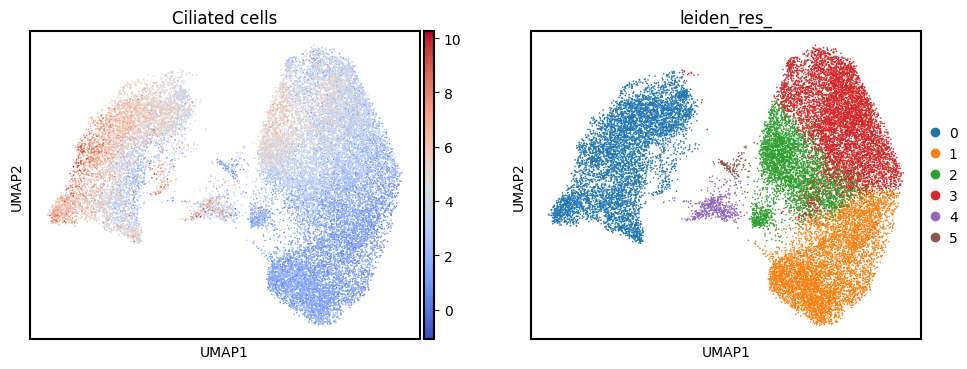

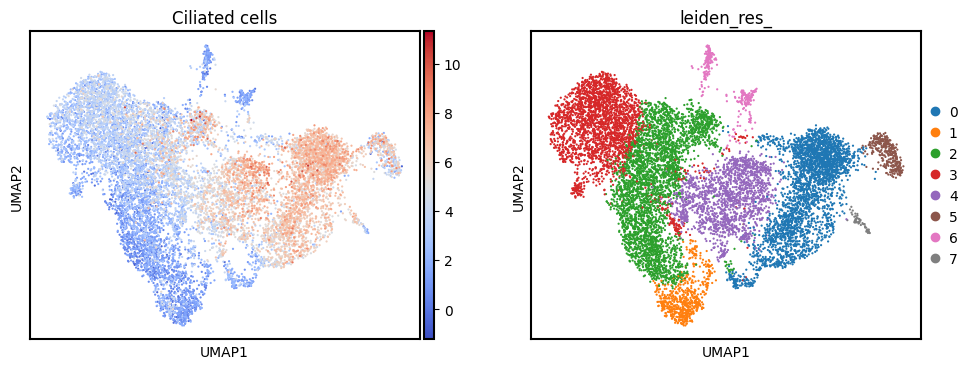

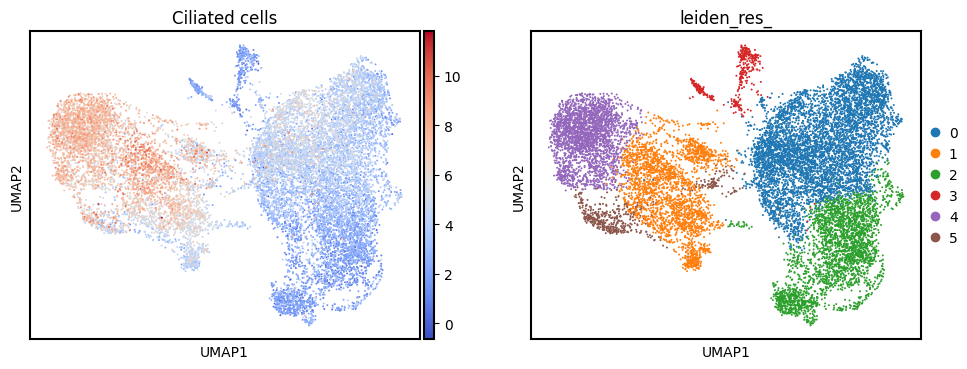

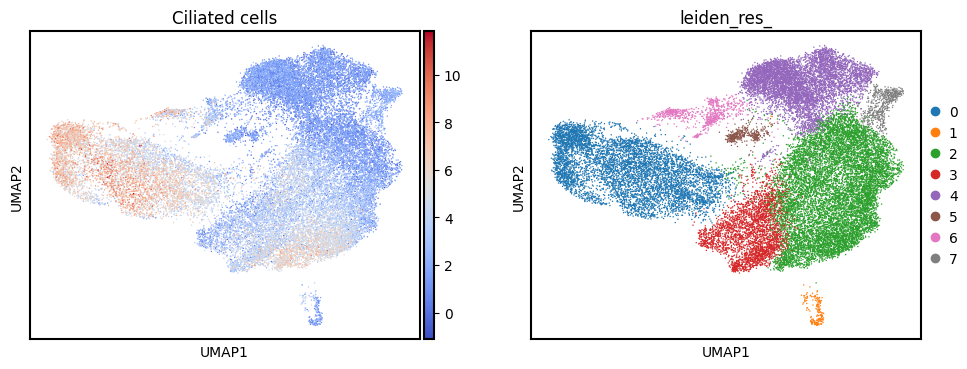

In [42]:
#check score for ciliated cells in mock_score
sc.pl.umap(mock_score, color=["Ciliated cells", "leiden_res_"], cmap="coolwarm")
sc.pl.umap(score_1, color=["Ciliated cells", "leiden_res_"], cmap="coolwarm")
sc.pl.umap(score_2, color=["Ciliated cells", "leiden_res_"], cmap="coolwarm")
sc.pl.umap(score_3, color=["Ciliated cells", "leiden_res_"], cmap="coolwarm")

In [43]:
# Mapping
mock_cluster = mock_adata_gene_rank[mock_adata_gene_rank["stat"] > 0].groupby("group").head(1).set_index("group")["name"].to_dict()
mock_cluster

cluster_one = day_one_gene_rank[day_one_gene_rank["stat"] > 0].groupby("group").head(1).set_index("group")["name"].to_dict()
cluster_one

cluster_two = day_two_gene_rank[day_two_gene_rank["stat"] > 0].groupby("group").head(1).set_index("group")["name"].to_dict()
cluster_two

/var/folders/gr/ktjxxk710qq2wtxt54fg91880000gn/T/ipykernel_3723/1262334117.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mock_cluster = mock_adata_gene_rank[mock_adata_gene_rank["stat"] > 0].groupby("group").head(1).set_index("group")["name"].to_dict()
/var/folders/gr/ktjxxk710qq2wtxt54fg91880000gn/T/ipykernel_3723/1262334117.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_one = day_one_gene_rank[day_one_gene_rank["stat"] > 0].groupby("group").head(1).set_index("group")["name"].to_dict()
/var/folders/gr/ktjxxk710qq2wtxt54fg91880000gn/T/ipykernel_3723/1262334117.py:8: FutureWarning: The defau

{'0': 'Clara cells',
 '1': 'Ciliated cells',
 '2': 'Gastric chief cells',
 '3': 'Tuft cells',
 '4': 'Ciliated cells',
 '5': 'Enterochromaffin cells'}

In [44]:
cluster_three = day_three_gene_rank[day_three_gene_rank["stat"] > 0].groupby("group").head(1).set_index("group")["name"].to_dict()
cluster_three

/var/folders/gr/ktjxxk710qq2wtxt54fg91880000gn/T/ipykernel_3723/950273438.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_three = day_three_gene_rank[day_three_gene_rank["stat"] > 0].groupby("group").head(1).set_index("group")["name"].to_dict()


{'0': 'Ciliated cells',
 '1': 'Enteroendocrine cells',
 '2': 'Ionocytes',
 '3': 'Airway goblet cells',
 '4': 'Enterochromaffin cells',
 '5': 'Tuft cells',
 '6': 'Enterochromaffin cells',
 '7': 'Microfold cells'}

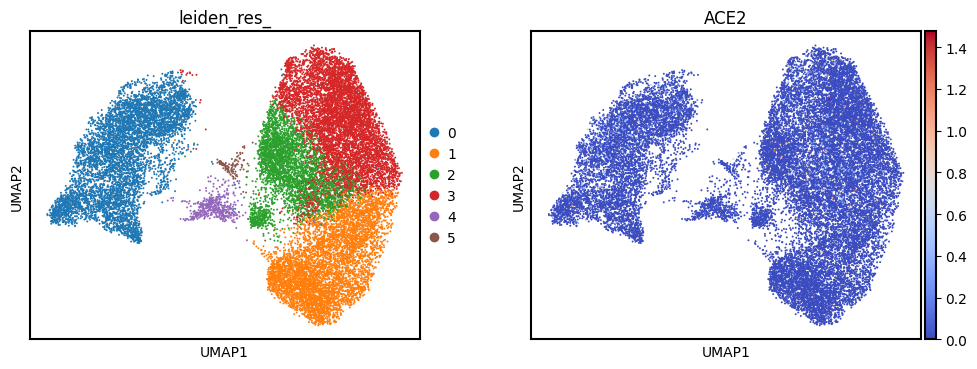

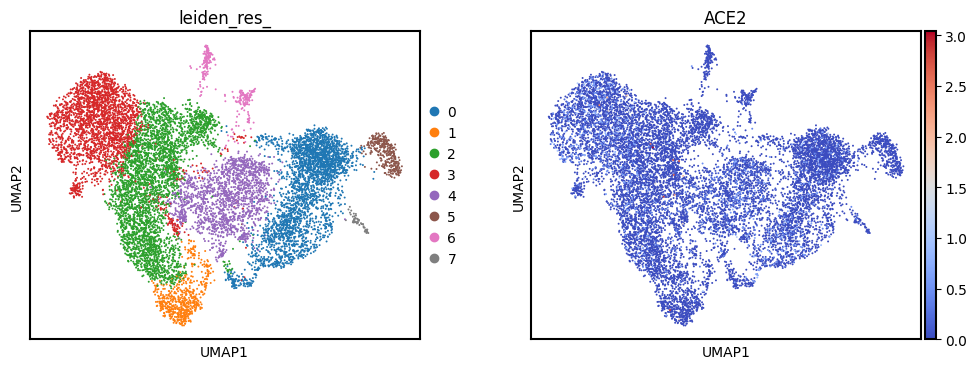

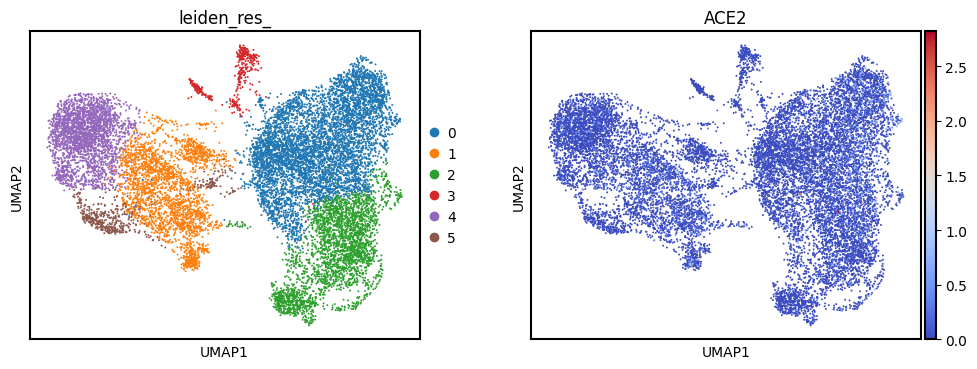

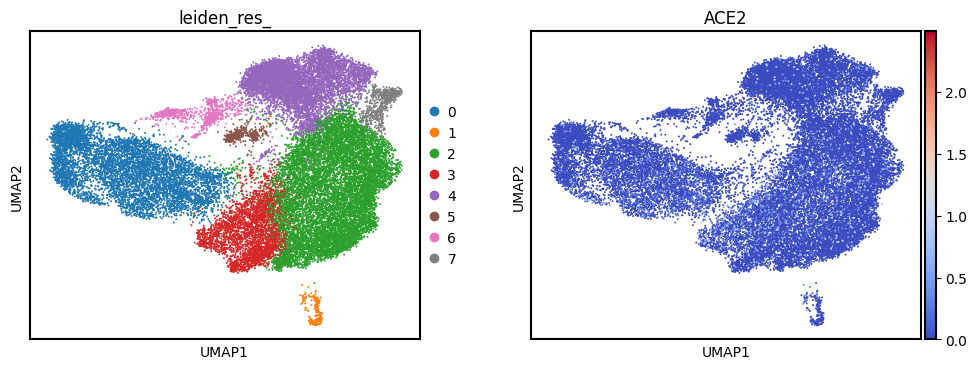

In [45]:
#plot ACE2 across dataset

#mock
sc.pl.umap(
    mock_adata,
    color=['leiden_res_', 'ACE2',],
    cmap="coolwarm",
    size=8
    )

#day_one
sc.pl.umap(
    day_one,
    color=['leiden_res_', 'ACE2'],
    cmap="coolwarm",
    size=8
    )

#day_two
sc.pl.umap(
    day_two,
    color=['leiden_res_', 'ACE2'],
    cmap="coolwarm",
    size=8
    )

#day_three
sc.pl.umap(
    day_three,
    color=['leiden_res_', 'ACE2'],
    cmap="coolwarm",
    size=8
    )

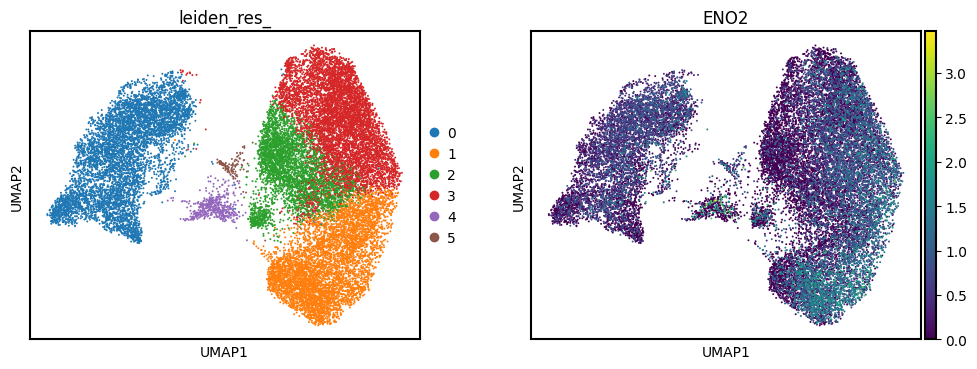

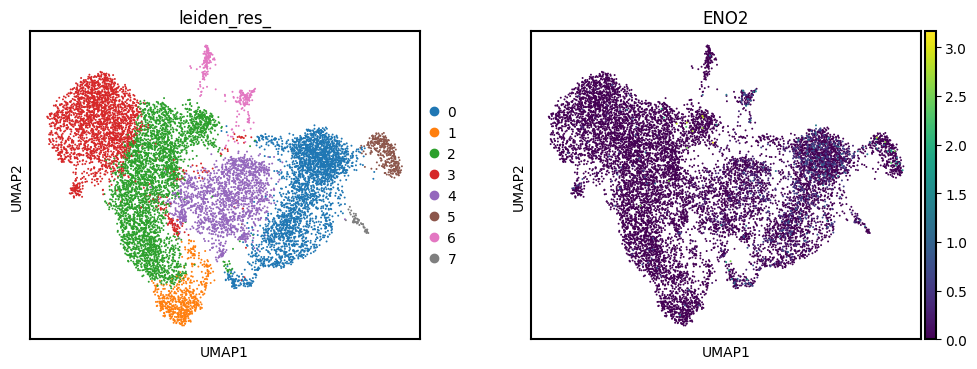

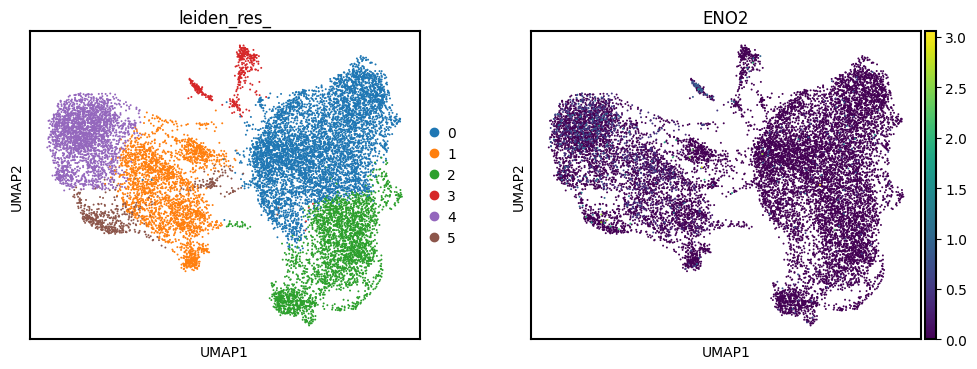

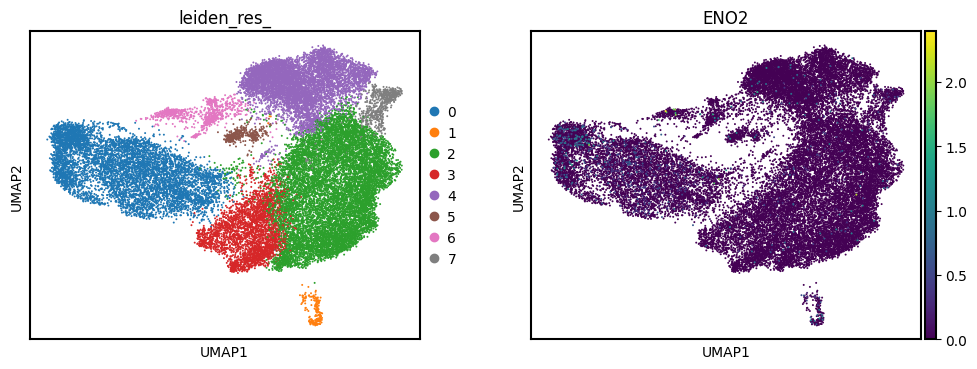

In [46]:
#ENO across post-infection days
sc.pl.umap(
    mock_adata,
    color=['leiden_res_', 'ENO2',],
    cmap="viridis",
    size=8
    )

#day_one
sc.pl.umap(
    day_one,
    color=['leiden_res_', 'ENO2'],
    cmap="viridis",
    size=8
    )

#day_two
sc.pl.umap(
    day_two,
    color=['leiden_res_', 'ENO2'],
    cmap="viridis",
    size=8
    )

#day_three
sc.pl.umap(
    day_three,
    color=['leiden_res_', 'ENO2'],
    cmap="viridis",
    size=8
    )

In [47]:
# Create a modified, unique mapping dictionary
cluster_three_fixed = {}
used_names = set()

for cluster_id, cell_type_name in cluster_three.items():
    if cell_type_name in used_names:
        # If the name is already used, assign a unique name by appending the ID
        new_name = f"{cell_type_name} (Subtype)"
    else:
        # Otherwise, use the original name
        new_name = cell_type_name
        used_names.add(new_name)

    cluster_three_fixed[cluster_id] = new_name

print("--- Fixed Cluster Mapping (to ensure uniqueness) ---")
print(cluster_three_fixed)

--- Fixed Cluster Mapping (to ensure uniqueness) ---
{'0': 'Ciliated cells', '1': 'Enteroendocrine cells', '2': 'Ionocytes', '3': 'Airway goblet cells', '4': 'Enterochromaffin cells', '5': 'Tuft cells', '6': 'Enterochromaffin cells (Subtype)', '7': 'Microfold cells'}


In [48]:
#Renaming
mock_adata.obs["leiden_res_"] = mock_adata.obs["leiden_res_"].astype(str).astype("category").cat.rename_categories(
    mock_cluster)

day_three.obs["leiden_res_"] = day_three.obs["leiden_res_"].astype(str).astype("category").cat.rename_categories(
    cluster_three_fixed)

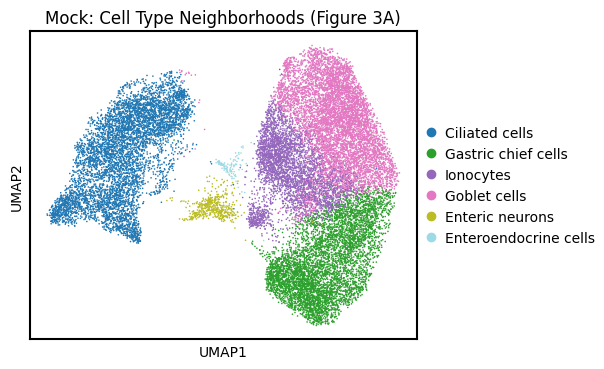

In [58]:
sc.pl.umap(
    mock_adata,
    color="leiden_res_",
    title='Mock: Cell Type Neighborhoods (Figure 3A)',
)

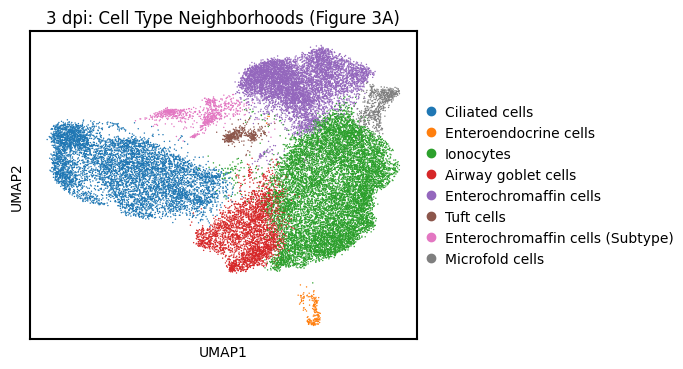

In [59]:
# 3 dpi UMAP
sc.pl.umap(
    day_three,
    color="leiden_res_",
    title='3 dpi: Cell Type Neighborhoods (Figure 3A)',
)

In [51]:
Ciliated_cells_markers = markers[markers['source'].isin(['Ciliated Cells'])].head()
Gastric_chief_cells_markers = markers[markers['source'].isin(['Gastric chief cells'])].head()
Goblet_cells_markers = markers[markers['source'].isin(['Goblet cells'])].head()
Enteric_Neurons_markers = markers[markers['source'].isin(['Enteric Neurons'])].head()
Ionocytes_markers = markers[markers['source'].isin(['Ionocytes'])].head()
Tuft_cells_markers = markers[markers['source'].isin(['Tuft cells'])].head()

In [52]:
#filtered_mock_genes = {}

#for celltype, genes in cell_dict.items():
    # Check which genes from the master list are present in the mock_adata
    #valid = [g for g in genes if g in mock_adata.var_names]

    #if len(valid) > 0:
        #filtered_mock_genes[celltype] = valid

#print(filtered_mock_genes)

In [53]:
#filtered_3dpi_genes = {}

#for celltype, genes in cells_dict.items():
    # Check which genes from the master list are present in the 3dpi dataset
    #valid = [g for g in genes if g in day_three.var_names]

    #if len(valid) > 0:
        #filtered_3dpi_genes[celltype] = valid
#print(filtered_3dpi_genes)

In [54]:
#create a canocial marker dictionary
cells_dict_mock = {
     'Ciliated cells': ['FOXJ1', 'DNAH5', 'CCDC40', 'TPPP3', 'MCIDAS'],
     'Gastric chief cells': ['PGC'],
     'Ionocytes': ['FOXI1', 'CFTR', 'ASCL3', 'ATP6V1B1', 'BSND'],
     'Goblet cells': ['MUC5AC', 'MUC5B', 'SPDEF', 'AGR2', 'TFF3'],
     'Enteric neurons': ['RET', 'TUBB3', 'ELAVL4'],
     'Enteroendocrine cells': ['CHGA', 'CHGB', 'TPH1']
     }


In [55]:
sc.tl.dendrogram(mock_adata, groupby="leiden_res_")

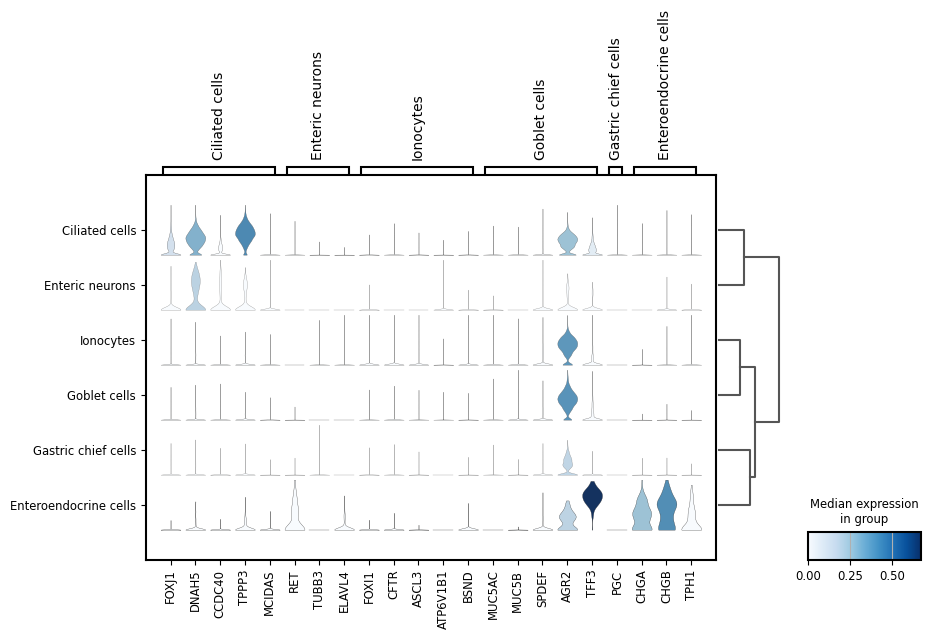

In [60]:
#Figure 3B
sc.pl.stacked_violin(
    mock_adata,
    var_names=cells_dict_mock,
    groupby="leiden_res_",
    dendrogram=True,
    standard_scale="var",
    swap_axes=False,
    figsize=(10, 5)
)

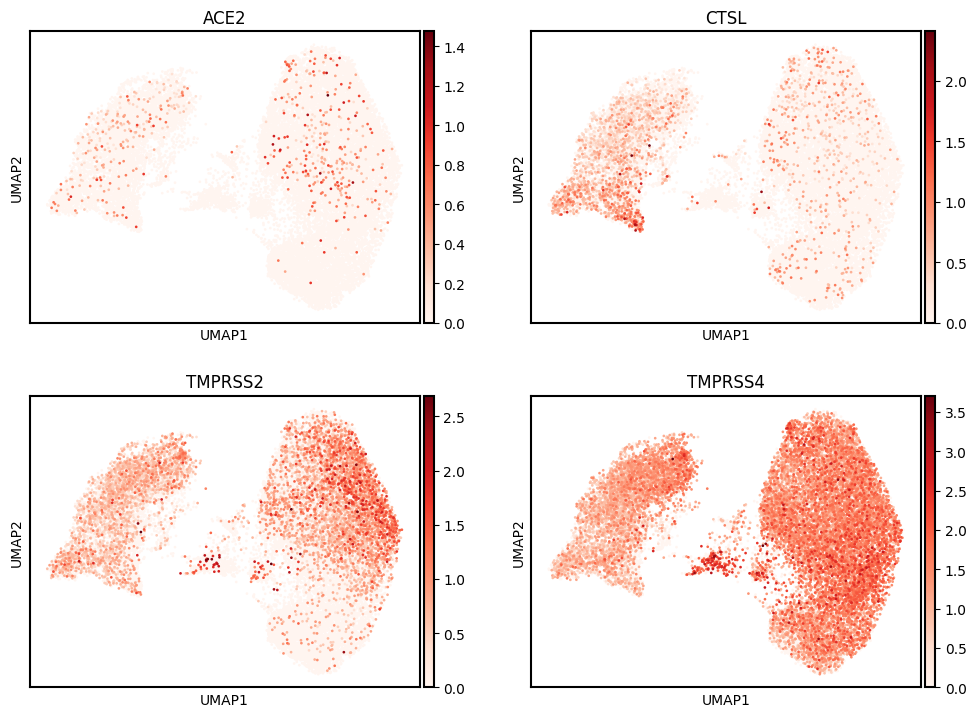

In [80]:
#Figure 4A
# Define the list of genes you want to color the UMAP by
genes_to_plot = ['ACE2', 'CTSL', 'TMPRSS2', 'TMPRSS4']

# Run the UMAP plotting function
sc.pl.umap(
    mock_adata,
    color=genes_to_plot,
    title=genes_to_plot,
    cmap='Reds',
    ncols=2,
    size=15,
)

In [81]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#------------------------------------------
# 1. Select genes of interest
#------------------------------------------
genes = ["ACE", "ANPEP", "CLTRN", "DPP4"]

# Keep only genes present in the dataset
genes_present = [g for g in genes if g in mock_adata.var_names]
print("Genes found:", genes_present)

#------------------------------------------
# 2. Subset to ciliated cells only
#------------------------------------------
cil = mock_adata[mock_adata.obs["celltype"] == "Ciliated cells"].copy()

#------------------------------------------
# 3. Compute z-score across ALL ciliated cells
#------------------------------------------
X = cil[:, genes_present].X.toarray() if hasattr(cil[:, genes_present].X,"toarray") else cil[:, genes_present].X
gene_means = np.mean(X, axis=0)
gene_stds = np.std(X, axis=0)

z = (X - gene_means) / gene_stds

# Store back into AnnData
for i, g in enumerate(genes_present):
    cil.obs[g + "_z"] = z[:, i]

#------------------------------------------
# 4. Group by (infection_status × dpi)
#------------------------------------------
groups = cil.obs.groupby(["infection_status", "dpi"])[[g + "_z" for g in genes_present]].mean()

# Convert to a matrix with structure:
# rows = genes
# columns = conditions like "infected_1dpi"
matrix = groups.T.copy()
matrix.columns = [f"{i}_{d}dpi" for i, d in matrix.columns]

#------------------------------------------
# 5. Plot heatmaps (one per gene panel or combined)
#------------------------------------------
plt.figure(figsize=(14, 5))
sns.heatmap(matrix, cmap="RdBu_r", center=0, linewidths=0.5)
plt.title("Z-scored mean expression of coronavirus-related receptors in ciliated cells")
plt.xlabel("Condition")
plt.ylabel("Gene")
plt.tight_layout()
plt.show()


Genes found: ['ACE', 'ANPEP', 'CLTRN', 'DPP4']


KeyError: 'celltype'

In [82]:
mock_adata.obs.columns

Index(['n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts',
       'log1p_total_counts', 'pct_counts_in_top_50_genes',
       'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes',
       'pct_counts_in_top_500_genes', 'total_counts_MT',
       'log1p_total_counts_MT', 'pct_counts_MT', 'total_counts_RIBO',
       'log1p_total_counts_RIBO', 'pct_counts_RIBO', 'total_counts_HB',
       'log1p_total_counts_HB', 'pct_counts_HB', 'n_genes', 'condition',
       'leiden_res_'],
      dtype='object')

... storing 'time_point' as categorical
... storing 'infection_status' as categorical
... storing 'condition_time_status' as categorical


Markers found: ['FOXJ1', 'PIFO', 'TPPP3', 'RSPH1', 'RFX2', 'RFX3']


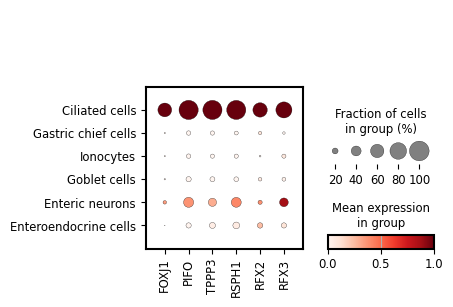

In [83]:
import scanpy as sc

markers = ["FOXJ1","PIFO","TPPP3","RSPH1","RFX2","RFX3"]
markers = [g for g in markers if g in adata.var_names]
print("Markers found:", markers)

sc.pl.dotplot(
    adata,
    var_names=markers,
    groupby="leiden_res_",
    standard_scale="var"
)

In [84]:
mock_adata.obs["condition"].value_counts()

condition
mock    22608
Name: count, dtype: int64

Genes found in dataset: ['ACE', 'ANPEP', 'CLTRN', 'DPP4']


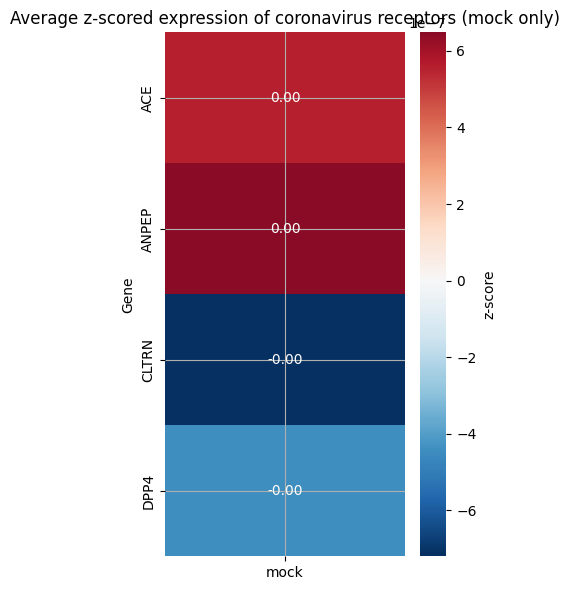

In [85]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#------------------------------------------
# 1. Define genes of interest
#------------------------------------------
genes = ["ACE", "ANPEP", "CLTRN", "DPP4"]

# Keep only genes present in your dataset
genes_present = [g for g in genes if g in mock_adata.var_names]
print("Genes found in dataset:", genes_present)

#------------------------------------------
# 2. Extract expression matrix for these genes
#------------------------------------------
X = mock_adata[:, genes_present].X
if hasattr(X, "toarray"):
    X = X.toarray()

#------------------------------------------
# 3. Compute z-score across ALL mock cells
#    z = (x - mean) / sd  (per gene)
#------------------------------------------
gene_means = np.mean(X, axis=0)
gene_stds = np.std(X, axis=0)
z_matrix = (X - gene_means) / gene_stds

#------------------------------------------
# 4. Compute average z-score for mock cells
#------------------------------------------
avg_z = z_matrix.mean(axis=0)

df = pd.DataFrame(avg_z, index=genes_present, columns=["mock"])

#------------------------------------------
# 5. Plot heatmap
#------------------------------------------
plt.figure(figsize=(4, 6))
sns.heatmap(df, cmap="RdBu_r", center=0, annot=True, fmt=".2f",
            cbar_kws={"label": "z-score"})
plt.title("Average z-scored expression of coronavirus receptors (mock only)")
plt.ylabel("Gene")
plt.xlabel("")
plt.tight_layout()
plt.show()
